In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../data/spam_mail.csv")
df.rename(columns = {"Category":'category',"Masseges":'messages'},inplace=True)

In [22]:
x = df['messages']
y = df['category']
y = y.map({"ham":0,"spam":1})

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    random_state = 42,
    test_size = 0.2,
    stratify = y
)

In [23]:
from tensorflow.keras.layers import TextVectorization

In [24]:
vocab_size = 5000
vectoriser = TextVectorization(
    max_tokens = vocab_size,
    output_sequence_length = 50,
)
# adapt = learn vocabulary
vectoriser.adapt(x_train) # this is same as fit_on_text in tokenizer

In [25]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

In [26]:
class selfAttention(Layer):
    def __init__(self,d_model):
        super().__init__()
        self.Wq = tf.keras.layers.Dense(d_model)
        self.Wk = tf.keras.layers.Dense(d_model)
        self.Wv = tf.keras.layers.Dense(d_model)
    def call(self,x):
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wk(x)

        scores = tf.matmul(Q,K,transpose_b=True)
        weights = tf.nn.softmax(scores,axis = -1)

        output = tf.matmul(weights,V)
        return output

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, GlobalAveragePooling1D

In [28]:
trnsfrm = Sequential([
    vectoriser,
    Embedding(input_dim = vocab_size, output_dim = 32,mask_zero=True),
    selfAttention(32),
    GlobalAveragePooling1D(),
    Dense(64,activation='relu'),
    Dense(1,activation = 'sigmoid')
])

In [29]:
trnsfrm.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [30]:
x_train_val = x_train.values # or else you get ValueError: Invalid dtype: object
y_train_val = y_train.values 

x_test_val = x_test.values 
y_test_val = y_test.values 


Epoch 1/5


/opt/anaconda3/envs/cnn_env/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'self_attention_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8691 - loss: 0.3257 - val_accuracy: 0.9013 - val_loss: 0.2185
Epoch 2/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9686 - loss: 0.0992 - val_accuracy: 0.9731 - val_loss: 0.1019
Epoch 3/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9820 - loss: 0.0558 - val_accuracy: 0.9798 - val_loss: 0.0554
Epoch 4/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9920 - loss: 0.0268 - val_accuracy: 0.9798 - val_loss: 0.0537
Epoch 5/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9960 - loss: 0.0145 - val_accuracy: 0.9865 - val_loss: 0.0374


In [ ]:
trnsfrm.fit(
    x_train_val,
    y_train_val,
    epochs = 5,
    batch_size = 32,
    validation_split = 0.1 
)

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,precision_score, recall_score
import matplotlib.pyplot as plt

In [42]:
trnsfrm_pred = trnsfrm.predict(x_test_val)
trnsfrm_pred_threshold = (trnsfrm_pred>=0.2).astype(int)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


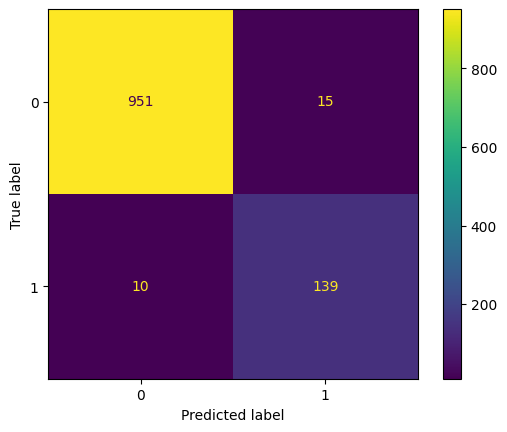

In [44]:
trnsfrm_cm = confusion_matrix(y_test,trnsfrm_pred_threshold)
disp = ConfusionMatrixDisplay(trnsfrm_cm)
disp.plot()
plt.show()

In [46]:
precision = precision_score(y_test,trnsfrm_pred_threshold)
recall = recall_score(y_test,trnsfrm_pred_threshold)
print(precision,recall)

0.9025974025974026 0.9328859060402684
